In [1]:
from pathlib import Path
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from torch.utils.data import TensorDataset, DataLoader

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import optuna
import wandb
import os
os.environ["WANDB_MODE"] = "offline"

from DataProcessing import Dataprocessing

/Users/cacslab/miniconda3/envs/pytorch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SEQ_LEN = 128
STRIDE = 1
INPUT_DIM = 51

BATCH_SIZE = 512
EPOCHS = 40
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
CONV_CHANNELS = 64
KERNEL_SIZE = 3
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
THRESHOLD_QUANTILE = 0.99
PATIENCE = 8

device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
print("device:", device)


device: mps


#### Data processing

In [2]:
start_time = pd.to_datetime("2015-12-23 12:00:00")
drop_columns = ["Detailed_Label"]
SEQ_LEN = 128
STRIDE = 1

X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq = Dataprocessing(start_time, drop_columns, SEQ_LEN, STRIDE)


------------------------- Original Data -------------------------
Normal Data = (495000, 54)
Attack Data = (449919, 54)

------------------------- Processing ... -------------------------
Normal data = (424800, 54)
Number of skip data = 70200
(874719, 53)
Number of total data = (874719, 53)
train_set = (339840, 54)
val_set = (42480, 54)
Test data has 438514 normal data and 53885 abnomaly data.
train gaps: 0
val gaps: 0
test gaps: 1

------------------------- Final Result -------------------------
X_train_seq: (339713, 128, 51) y_train_seq: (339713,) skipped: 0
X_val_seq  : (42353, 128, 51) y_val_seq  : (42353,) skipped: 0
X_test_seq : (492145, 128, 51) y_test_seq : (492145,) skipped: 127


In [8]:
# numpy -> tensor，並塑形
train_dataset = TensorDataset(torch.from_numpy(X_train_seq), torch.from_numpy(np.zeros(len(X_train_seq), dtype=np.int64)))
val_dataset = TensorDataset(torch.from_numpy(X_val_seq), torch.from_numpy(np.zeros(len(X_val_seq), dtype=np.int64)))
test_dataset = TensorDataset(torch.from_numpy(X_test_seq), torch.from_numpy(y_test_seq))

In [9]:

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


#### Model architecture with optuna framework

In [ ]:
def get_search_space(trial):
    params = {
        # Conv1D feature extractor
        "conv_channels": trial.suggest_categorical(
            "conv_channels", 
            [32, 64, 128, 256]
        ),

        "kernel_size": trial.suggest_categorical(
            "kernel_size", 
            [3, 5, 7]
        ),

        # LSTM encoder / decoder
        "hidden_size": trial.suggest_categorical(
            "hidden_size", 
            [32, 64, 128, 256]
        ),

        "num_layers": trial.suggest_int(
            "num_layers", 
            1, 5
        ),

        "dropout": trial.suggest_float(
            "dropout", 
            0.0, 0.5
        ),

        "bidirectional": trial.suggest_categorical(
            "bidirectional", 
            [False, True]
        ),

        # Optimizer
        "learning_rate": trial.suggest_float(
            "learning_rate", 
            1e-5, 1e-3, 
            log=True
        ),

        "weight_decay": trial.suggest_float(
            "weight_decay", 
            1e-7, 1e-3, 
            log=True
        ),
        
        "threshold_percentile": trial.suggest_float(
            "threshold_percentile",
            90.0,
            99.5
        ),
    }

    return params

In [11]:
class ConvFeatureExtractor(nn.Module):
    def __init__(self, input_dim: int, conv_channels: int, kernel_size: int, dropout: float):
        super().__init__()
        padding = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv1d(input_dim, conv_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(conv_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(conv_channels, conv_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(conv_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.net(x)
        return x.transpose(1, 2)


class Encoder(nn.Module):
    def __init__(self, conv_channels: int, hidden_size: int, num_layers: int, dropout: float, bidirectional: bool):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional, # BiLSTM，Encoder 和 Decoder 的方向性需一樣，否則維度會報錯
            dropout=dropout if num_layers > 1 else 0.0,
        )

    def forward(self, x):
        _, (hidden, cell) = self.lstm(x)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, conv_channels: int, hidden_size: int, num_layers: int, dropout: float, bidirectional: bool):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional, # BiLSTM
            dropout=dropout if num_layers > 1 else 0.0,
        )
        # BiLSTM 的 hidden size 會翻倍 
        direction_factor = 2 if bidirectional else 1
        self.output_layer = nn.Linear(hidden_size * direction_factor, conv_channels)

    def forward(self, decoder_input, hidden, cell):
        decoded, _ = self.lstm(decoder_input, (hidden, cell))
        return self.output_layer(decoded)


class ReconstructionHead(nn.Module):
    def __init__(self, conv_channels: int, output_dim: int, kernel_size: int):
        super().__init__()
        padding = kernel_size // 2
        self.proj = nn.Conv1d(conv_channels, output_dim, kernel_size=kernel_size, padding=padding)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.proj(x)
        return x.transpose(1, 2)


class LSTMAutoencoder(nn.Module):
    def __init__(
        self,
        input_dim: int,
        conv_channels: int,
        kernel_size: int,
        hidden_size: int,
        num_layers: int,
        dropout: float,
        bidirectional: bool, # BiLSTM
    ):
        super().__init__()
        self.feature_extractor = ConvFeatureExtractor(input_dim, conv_channels, kernel_size, dropout)
        self.encoder = Encoder(conv_channels, hidden_size, num_layers, dropout, bidirectional=bidirectional)
        self.decoder = Decoder(conv_channels, hidden_size, num_layers, dropout, bidirectional=bidirectional)
        self.reconstruction_head = ReconstructionHead(conv_channels, input_dim, kernel_size)

    def forward(self, x):
        # 特徵提取
        conv_features = self.feature_extractor(x)
        # Encoder 壓縮
        hidden, cell = self.encoder(conv_features)
        # Decoder 重建
        decoder_input = torch.zeros_like(conv_features)
        decoded_features = self.decoder(decoder_input, hidden, cell)
        # 重建
        reconstruction = self.reconstruction_head(decoded_features)
        return reconstruction


In [12]:
# model = LSTMAutoencoder(
#     input_dim=INPUT_DIM,
#     conv_channels=CONV_CHANNELS,
#     kernel_size=KERNEL_SIZE,
#     hidden_size=HIDDEN_SIZE,
#     num_layers=NUM_LAYERS,
#     dropout=DROPOUT,
#     bidirectional=False, # BiLSTM
# ).to(device)

# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# print(model)


In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for (batch_x, _) in loader:
        batch_x = batch_x.to(device)

        optimizer.zero_grad()
        reconstruction = model(batch_x)
        loss = criterion(reconstruction, batch_x)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(loader.dataset)


def evaluate_reconstruction_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for (batch_x, _) in loader:
            batch_x = batch_x.to(device)
            reconstruction = model(batch_x)
            loss = criterion(reconstruction, batch_x)
            total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(loader.dataset)


In [ ]:
history = {"train_loss": [], "val_loss": []}

def compute_window_score(reconstruction, batch_x, mode="mean", top_k=5):
    point_error = (reconstruction - batch_x) ** 2
    timestep_error = point_error.mean(dim=2)

    if mode == "mean":
        return timestep_error.mean(dim=1)
    if mode == "max":
        return timestep_error.max(dim=1).values
    if mode == "topk":
        k = min(top_k, timestep_error.shape[1])
        topk_vals = torch.topk(timestep_error, k=k, dim=1).values
        return topk_vals.mean(dim=1)

    raise ValueError(f"Unsupported mode: {mode}")


def get_reconstruction_errors(model, data_array: np.ndarray, device, batch_size: int = 512, score_mode: str = "mean", top_k: int = 5):
    model.eval()
    scores = []
    dataset = TensorDataset(torch.from_numpy(data_array).float())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            reconstruction = model(batch_x)
            batch_error = compute_window_score(reconstruction, batch_x, mode=score_mode, top_k=top_k)
            scores.append(batch_error.detach().cpu().numpy())

    return np.concatenate(scores)


def fit_model(params, trial=None, capture_history=False):
    model = LSTMAutoencoder(
        input_dim=INPUT_DIM,
        conv_channels=params["conv_channels"],
        kernel_size=params["kernel_size"],
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout=params["dropout"],
        bidirectional=params["bidirectional"],
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])

    local_history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state_dict = None
    wait = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate_reconstruction_loss(model, val_loader, criterion, device)

        if capture_history:
            local_history["train_loss"].append(train_loss)
            local_history["val_loss"].append(val_loss)

        print(f"Epoch [{epoch:02d}/{EPOCHS}] train_loss={train_loss:.6f} val_loss={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break
        
        

        if trial is not None:
            trial.report(best_val_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
    

    model.load_state_dict(best_state_dict)
    return model, best_val_loss, local_history


def objective(trial):
    params = get_search_space(trial)
    score_mode = trial.suggest_categorical("score_mode", ["mean", "max", "topk"])
    top_k = trial.suggest_int("top_k", 3, 20)
    threshold_percentile = params["threshold_percentile"] / 100.0
    
    model, best_val_loss, _ = fit_model(params, trial=trial, capture_history=False)
    
    val_errors = get_reconstruction_errors(model, X_val_seq, device, score_mode=score_mode, top_k=top_k)
    threshold = float(np.quantile(val_errors, threshold_percentile))
    
    test_errors = get_reconstruction_errors(model, X_test_seq, device, batch_size=BATCH_SIZE, score_mode=score_mode, top_k=top_k)
    
    y_pred = (test_errors > threshold).astype(int)

    f1 = f1_score(y_test_seq, y_pred, zero_division=0)
    precision = precision_score(y_test_seq, y_pred, zero_division=0)
    recall = recall_score(y_test_seq, y_pred, zero_division=0)

    trial.set_user_attr("best_val_loss", best_val_loss)
    trial.set_user_attr("threshold", threshold)
    trial.set_user_attr("f1", f1)
    trial.set_user_attr("precision", precision)
    trial.set_user_attr("recall", recall)

    return f1


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

best_params = study.best_params

print("Best F1:", study.best_value)
print("Best params:", best_params)
print("Best attrs:", study.best_trial.user_attrs)


[I 2026-05-06 22:35:42,652] A new study created in memory with name: no-name-4ef9e16e-ad5f-4272-a7b6-48427f717491


Epoch [01/40] train_loss=0.009841 val_loss=0.006300
Epoch [02/40] train_loss=0.002025 val_loss=0.004078


In [ ]:
best_model, best_val_loss, history = fit_model(best_params, capture_history=True)

best_score_mode = best_params["score_mode"]
best_top_k = best_params["top_k"]
best_threshold_percentile = best_params["threshold_percentile"] / 100.0

val_errors = get_reconstruction_errors(best_model, X_val_seq, device, batch_size=BATCH_SIZE, score_mode=best_score_mode, top_k=best_top_k)
test_errors = get_reconstruction_errors(best_model, X_test_seq, device, batch_size=BATCH_SIZE, score_mode=best_score_mode, top_k=best_top_k)

threshold = float(np.quantile(val_errors, best_threshold_percentile))
y_pred = (test_errors > threshold).astype(int)

acc = accuracy_score(y_test_seq, y_pred)
precision = precision_score(y_test_seq, y_pred, zero_division=0)
recall = recall_score(y_test_seq, y_pred, zero_division=0)
f1 = f1_score(y_test_seq, y_pred, zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"Threshold: {threshold:.6f}")

#### Experimental Result

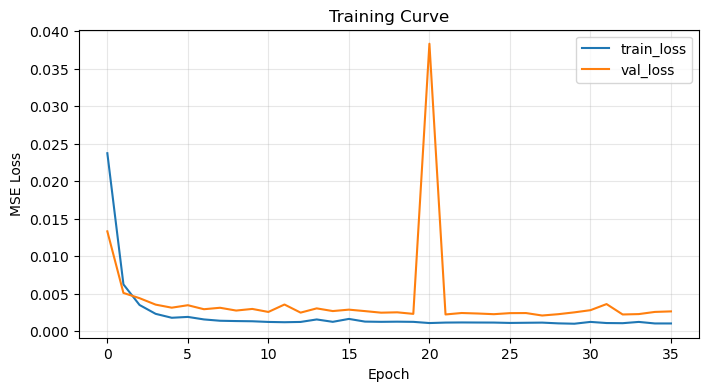

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# compute_window_score 已在 Optuna cell 定義；這格保留做實驗說明
print("Current anomaly score mode: mean")
print("You can switch score_mode to 'mean', 'max', or 'topk' in get_reconstruction_errors().")


In [ ]:
val_errors = get_reconstruction_errors(model, X_val_seq, device, score_mode="mean", top_k=5)
test_errors = get_reconstruction_errors(model, X_test_seq, device, score_mode="mean", top_k=5)
threshold = float(np.quantile(val_errors, THRESHOLD_QUANTILE))

print("val_errors shape:", val_errors.shape)
print("test_errors shape:", test_errors.shape)
print("threshold_percentile:", THRESHOLD_QUANTILE)
print("threshold:", threshold)


val_errors shape: (42353,)
test_errors shape: (492145,)
threshold: 0.08180571347475052


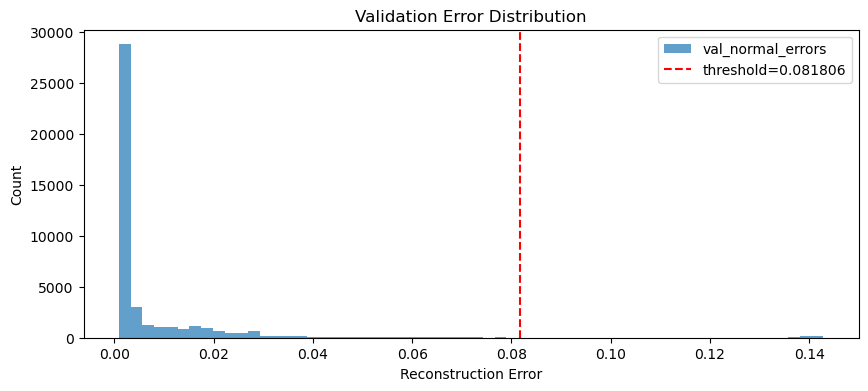

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(val_errors, bins=60, alpha=0.7, label="val_normal_errors")
plt.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.6f}")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Validation Error Distribution")
plt.legend()
plt.show()


In [ ]:
y_pred = (test_errors > threshold).astype(int)

acc = accuracy_score(y_test_seq, y_pred)
precision = precision_score(y_test_seq, y_pred, zero_division=0)
recall = recall_score(y_test_seq, y_pred, zero_division=0)
f1 = f1_score(y_test_seq, y_pred, zero_division=0)
cm = confusion_matrix(y_test_seq, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nClassification Report")
print(classification_report(y_test_seq, y_pred, digits=4, zero_division=0))
print("Confusion Matrix:\n", cm)


Accuracy : 0.9540
Precision: 0.9912
Recall   : 0.6157
F1-score : 0.7596

Classification Report
              precision    recall  f1-score   support

           0     0.9511    0.9993    0.9746    434082
           1     0.9912    0.6157    0.7596     58063

    accuracy                         0.9540    492145
   macro avg     0.9711    0.8075    0.8671    492145
weighted avg     0.9558    0.9540    0.9492    492145

Confusion Matrix:
 [[433763    319]
 [ 22313  35750]]


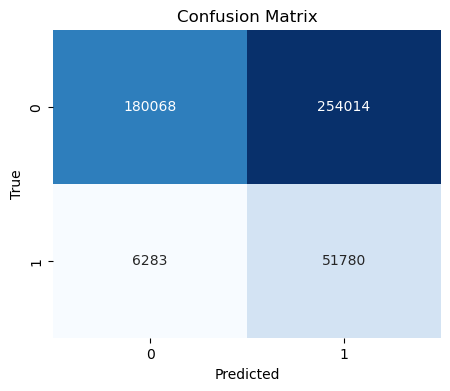

In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


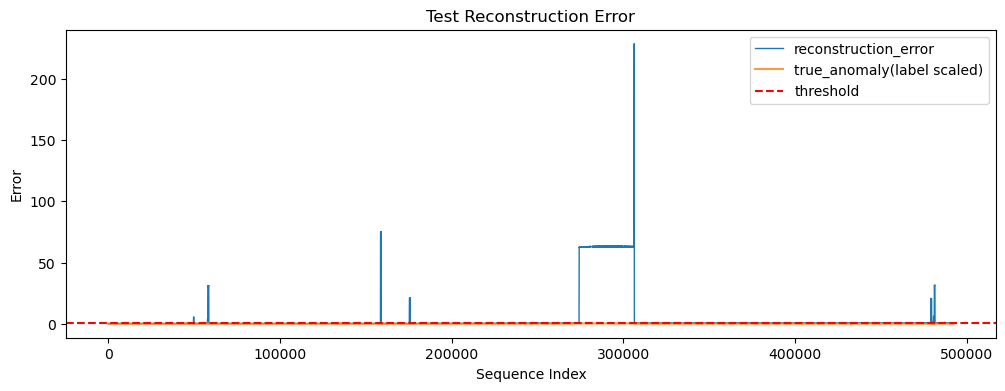

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(test_errors, label="reconstruction_error", linewidth=1)
plt.plot(y_test_seq * threshold, label="true_anomaly(label scaled)", alpha=0.8)
plt.axhline(threshold, color="red", linestyle="--", label="threshold")
plt.xlabel("Sequence Index")
plt.ylabel("Error")
plt.title("Test Reconstruction Error")
plt.legend()
plt.show()
